# Modelling data - Version 7

This version only includes the generation variables and ENSO.

<div>
Trabajo Integrador<br>
Maestría en Analítica e Inteligencia de Negocios<br>
Universidad del Valle<br>

</div>

#### Student
Camilo Andrés Jaramillo Tarapues - 2402218 

## Libraries

In [8]:
# Libraries

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from prophet import Prophet
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# Metrics
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

## Dataset

In [9]:
# Cargar el conjunto de datos
df = pd.read_csv('../../data/out/dataset_final.csv')
df

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,0.00,28880.74,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,0.00,29107.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,0.00,25939.87,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,0.00,25651.57,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,0.00,25245.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48187,2025-06-30 19:00:00,2025,6,30,19,112.55,1311491.62,9025510.46,2476.26,88117.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48188,2025-06-30 20:00:00,2025,6,30,20,112.55,1316147.03,8848494.08,1550.03,93431.69,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48189,2025-06-30 21:00:00,2025,6,30,21,106.25,1376475.95,8510792.32,0.00,95167.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48190,2025-06-30 22:00:00,2025,6,30,22,105.55,1401097.29,8058142.03,0.00,99156.29,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63


In [10]:
# Dropping column "SOLAR"

df = df.drop(columns=["YEAR", "MONTH", "DAY", "HORA",
                      "FUEL_CONS_ACPM", "FUEL_CONS_CARBON", "FUEL_CONS_COMBUSTOLEO", 
                      "FUEL_CONS_CRUDO", "FUEL_CONS_GAS", "FUEL_CONS_GAS_NI", "FUEL_CONS_GLP",
                      "FUEL_COST_CARBON", "FUEL_COST_GAS", "FUEL_COST_GAS_NI", "FUEL_COST_COMBUSTOLEO",
                      "IPC_VAR_MOM_PCT", "IPP_VAR_PN_MOM_PCT", "IPP_VAR_OI_MOM_PCT"])
df.head()

,FECHA_HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO
0,2020-01-01 00:00:00,72.02,2109637.93,4418103.51,0.0,28880.74,4291.34,1.0
1,2020-01-01 01:00:00,136.71,1864989.80,4548853.97,0.0,29107.37,3511.94,1.0
2,2020-01-01 02:00:00,127.71,1720883.01,4525898.75,0.0,25939.87,2641.90,1.0
3,2020-01-01 03:00:00,127.71,1649014.61,4458645.56,0.0,25651.57,3032.30,1.0
4,2020-01-01 04:00:00,127.71,1711745.36,4279657.90,0.0,25245.37,2514.76,1.0


In [11]:
print("Dataset info: ")
print(df.info())

Dataset info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48192 entries, 0 to 48191
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   FECHA_HORA   48192 non-null  object 
 1   PRECIO       48192 non-null  float64
 2   TERMICA      48192 non-null  float64
 3   HIDRAULICA   48192 non-null  float64
 4   SOLAR        48192 non-null  float64
 5   COGENERADOR  48192 non-null  float64
 6   EOLICA       48192 non-null  float64
 7   NIVEL_ENSO   48192 non-null  float64
dtypes: float64(7), object(1)
memory usage: 2.9+ MB
None


In [12]:
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
FECHA_HORA     0
PRECIO         0
TERMICA        0
HIDRAULICA     0
SOLAR          0
COGENERADOR    0
EOLICA         0
NIVEL_ENSO     0
dtype: int64


**There are no missing values and all data is numeric, so it is ready to train the models.**

## Scale data

In [13]:
# Define target column 'PRECIO'
TARGET_COLUMN = 'PRECIO'

# Variables that are truly categorical even though they are numerical
categorical_numeric = ["NIVEL_ENSO"]

# Identify the continuous numerical columns that we do scale
numeric_features = [
    col for col in df.columns 
    if col not in categorical_numeric and col != TARGET_COLUMN and col != 'FECHA_HORA'
]

# Preprocessor: We only scale continuous numerics
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", "passthrough", categorical_numeric)
    ]
)

## Train, test and split data

Dividing the balanced dataset into two subsets: one to train the model8(70% of the data) and another to evaluate it (remainin2 30%

In [17]:
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar el tamaño de cada conjunto
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (38553, 6)
Test set size: (9639, 6)


## Baseline Models

In [18]:
# Baseline models evaluation with multiple metrics

# Define dictionary of regression models
random_state=42

baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),  # may be slower on large datasets
    "KNN": KNeighborsRegressor(),  # may be slower on large datasets
}

# Define multiple metrics
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "mse": make_scorer(mean_squared_error),
    "rmse": make_scorer(lambda y, y_pred: root_mean_squared_error(y, y_pred))
}

In [19]:
results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse        rmse
Linear Regression -0.342277  162.027147   62941.561273  226.758369
Ridge             -0.342231  162.025935   62941.109817  226.756236
Lasso             -0.343103  161.965106   63005.979612  226.625634
ElasticNet        -0.150972  165.422209   65215.127902  222.476665
Decision Tree     -4.976023  231.403433  188249.958524  381.507921
Random Forest     -3.493891  207.400574  147340.306663  335.318738
Gradient Boosting -1.499566  180.635344   94577.848823  272.488229
SVR               -0.243393  164.693036   76169.787999  237.131502
KNN               -6.080443  229.576651  172734.995059  362.672035


In [20]:
#                         r2         mae            mse        rmse
#Linear Regression -0.674345  176.143089   81073.484241  255.868922
#Ridge             -0.673436  176.120759   81060.409212  255.836226
#Lasso             -0.325634  165.753530   75625.847518  242.202735
#ElasticNet         0.185139  145.374287   62001.490904  211.163299
#Decision Tree     -3.449350  228.943037  184205.415683  378.558964
#Random Forest     -2.352729  192.978591  125518.982163  309.732879
#Gradient Boosting -0.639346  162.598554   89007.378341  248.218739
#SVR               -0.671078  232.611620  131116.991248  304.197465
#KNN               -0.225339  161.433940   77056.569938  242.010131

### GridSearch CV

In [21]:
# Define hiperparameters
param_grids = {
    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    "RandomForest": {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10]
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200, 500],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7]
    }
}

# Define models
models = {
    "ElasticNet": ElasticNet(max_iter=10000, random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

In [22]:
# Para guardar resultados
best_models = {}
results = {}

for name, model in models.items():
    print("************************************************")
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="r2",
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X, y)
    
    best_models[name] = grid.best_estimator_
    results[name] = {
        "best_score": grid.best_score_,
        "best_params": grid.best_params_
    }
    print(f"Model: {name}")
    print(f"Best score: {grid.best_score_}")
    print(f"Best params: {grid.best_params_}")
    
results

************************************************
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Model: ElasticNet
Best score: -0.15097198018394759
Best params: {'model__alpha': 1, 'model__l1_ratio': 0.5}
************************************************
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Model: RandomForest
Best score: -2.048377188825718
Best params: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}
************************************************
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Model: GradientBoosting
Best score: -0.5926709836319971
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100}


{'ElasticNet': {'best_score': -0.15097198018394759,
  'best_params': {'model__alpha': 1, 'model__l1_ratio': 0.5}},
 'RandomForest': {'best_score': -2.048377188825718,
  'best_params': {'model__max_depth': 5,
   'model__min_samples_split': 2,
   'model__n_estimators': 100}},
 'GradientBoosting': {'best_score': -0.5926709836319971,
  'best_params': {'model__learning_rate': 0.01,
   'model__max_depth': 3,
   'model__n_estimators': 100}}}

In [23]:
#************************************************
#Fitting 5 folds for each of 30 candidates, totalling 150 fits
#Model: ElasticNet
#Best score: 0.2076746414849791
#Best params: {'model__alpha': 10, 'model__l1_ratio': 0.9}
#************************************************
#Fitting 5 folds for each of 36 candidates, totalling 180 fits
#Model: RandomForest
#Best score: -2.109574974486729
#Best params: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}
#************************************************
#Fitting 5 folds for each of 27 candidates, totalling 135 fits
#Model: GradientBoosting
#Best score: -0.46319237914950817
#Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}

### Boost models

In [24]:
robust_models = {
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

In [25]:
robust_results = {}

for name, model in robust_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    robust_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

pd.DataFrame(robust_results).T

,r2,mae,mse,rmse
XGBoost,-3.112193,201.342282,136924.582101,323.401193
LightGBM,-3.052371,196.323921,128920.905038,314.550132
CatBoost,-3.738223,205.514749,136566.939198,322.367411


## Time Series Forecasting

### Splits the training and test sets as a time series

In [26]:
# Separar variables y target
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Usar el índice para cortar: primeras 80% filas = train, últimas 20% filas = test
train_size = int(len(df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (38553, 6)
Test set size: (9639, 6)


In [27]:
# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae           mse        rmse
Linear Regression  0.107955  161.787612  71810.948170  227.938168
Ridge              0.107952  161.788085  71811.719776  227.939031
Lasso              0.130528  160.309305  71287.661371  226.493097
ElasticNet        -0.018142  173.748821  83176.275517  243.614697
Decision Tree     -0.316599  181.798873  92990.753636  258.448626
Random Forest     -0.016802  166.062442  84432.729119  240.807004
Gradient Boosting  0.084685  155.723257  72406.570242  226.231033
SVR               -0.385956  189.480676  96302.153543  268.328028
KNN               -0.155070  175.735757  83149.081746  245.815567


### Prophet

In [14]:
# Prepare data for Prophet: needs 'ds' (date) and 'y' (target)

df_prophet = df.copy()
#df_prophet = df_prophet.drop(columns=["YEAR", "MONTH", "DAY", "HORA"])
df_prophet.head()

,FECHA_HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO
0,2020-01-01 00:00:00,72.02,2109637.93,4418103.51,0.0,28880.74,4291.34,1.0
1,2020-01-01 01:00:00,136.71,1864989.80,4548853.97,0.0,29107.37,3511.94,1.0
2,2020-01-01 02:00:00,127.71,1720883.01,4525898.75,0.0,25939.87,2641.90,1.0
3,2020-01-01 03:00:00,127.71,1649014.61,4458645.56,0.0,25651.57,3032.30,1.0
4,2020-01-01 04:00:00,127.71,1711745.36,4279657.90,0.0,25245.37,2514.76,1.0


08:57:24 - cmdstanpy - INFO - Chain [1] start processing
08:58:54 - cmdstanpy - INFO - Chain [1] done processing


Prophet Forecasting Results:
MAE: 266.23, RMSE: 450.33, R2: 0.19


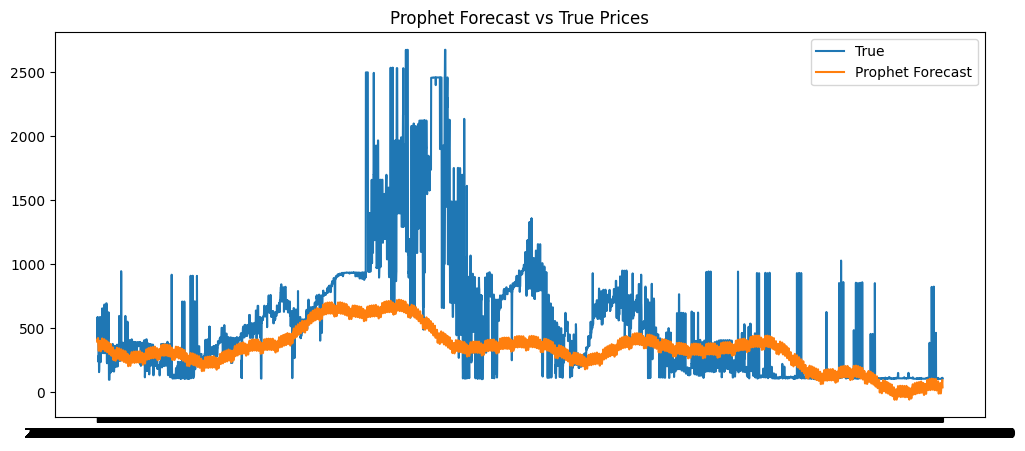

In [15]:
df_prophet = df_prophet.reset_index()[["FECHA_HORA", "PRECIO"]].rename(columns={"FECHA_HORA": "ds", "PRECIO": "y"})

# Train/test split: last 20% as test
train_size = int(len(df_prophet) * 0.8)
train_df, test_df = df_prophet.iloc[:train_size], df_prophet.iloc[train_size:]

# Fit Prophet model
prophet = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
prophet.fit(train_df)

# Forecast over test period
future = prophet.make_future_dataframe(periods=len(test_df), freq="h")
forecast = prophet.predict(future)

# Extract predictions only for test period
pred_prophet = forecast.set_index("ds").loc[test_df["ds"], "yhat"]

# Metrics
mae_p = mean_absolute_error(test_df["y"], pred_prophet)
rmse_p = root_mean_squared_error(test_df["y"], pred_prophet)
r2 = r2_score(test_df["y"], pred_prophet)

print("Prophet Forecasting Results:")
print(f"MAE: {mae_p:.2f}, RMSE: {rmse_p:.2f}, R2: {r2:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(test_df["ds"], test_df["y"], label="True")
plt.plot(test_df["ds"], pred_prophet, label="Prophet Forecast")
plt.legend()
plt.title("Prophet Forecast vs True Prices")
plt.show()

### Ensemble Prophet + XGBoost

XGBoost with Prophet feature:
MAE: 229.79, RMSE: 421.76, R2: 0.29


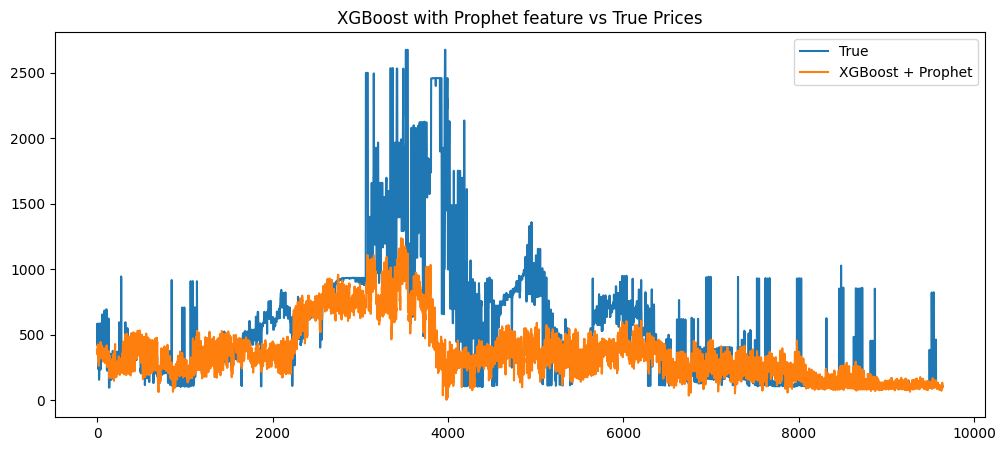

In [16]:
# --- Use Prophet as a feature for XGBoost ---

X_full = df.copy().drop(columns=["FECHA_HORA"])

# Add propehet prediction as a new column
X_full["prophet_yhat"] = forecast.set_index("ds")["yhat"].values

# Define train/test (temporal split)
X_train = X_full.iloc[:train_size].drop(columns=["PRECIO"])
y_train = X_full.iloc[:train_size]["PRECIO"]
X_test = X_full.iloc[train_size:].drop(columns=["PRECIO"])
y_test = X_full.iloc[train_size:]["PRECIO"]

# Train XGBoost
xgb_model = XGBRegressor(random_state=42, n_estimators=500, max_depth=6, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# --- Metrics ---
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost with Prophet feature:")
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# --- Paso 5: Graficamos ---
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="True")
plt.plot(y_pred_xgb, label="XGBoost + Prophet")
plt.legend()
plt.title("XGBoost with Prophet feature vs True Prices")
plt.show()

## Train and test with lags

In [37]:
# --- Create lag features ---
def create_lags(df, target_col, n_lags=24):
    df_lagged = df.copy()
    for lag in range(1, n_lags+1):
        df_lagged[f"{target_col}_lag{lag}"] = df_lagged[target_col].shift(lag)
    return df_lagged.dropna()

df_lagged = create_lags(df, target_col="PRECIO", n_lags=24)
df_lagged = df_lagged.dropna()

# Features (all except date & target)
X = df_lagged.drop(columns=["FECHA_HORA", "PRECIO"])
y = df_lagged["PRECIO"]

# --- Train/Test split ---
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [38]:
X_train.head()

,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO,PRECIO_lag1,PRECIO_lag2,PRECIO_lag3,PRECIO_lag4,...,PRECIO_lag15,PRECIO_lag16,PRECIO_lag17,PRECIO_lag18,PRECIO_lag19,PRECIO_lag20,PRECIO_lag21,PRECIO_lag22,PRECIO_lag23,PRECIO_lag24
24,1608662.67,4585681.98,0.0,19184.34,4908.48,1.0,136.71,213.73,213.73,213.73,...,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71,136.71,72.02
25,1508655.14,4466153.60,0.0,19342.06,3836.61,1.0,71.34,136.71,213.73,213.73,...,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71,136.71
26,1413968.65,4520386.10,0.0,20345.52,5343.35,1.0,71.34,71.34,136.71,213.73,...,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71
27,1369278.08,4470436.67,0.0,21123.41,3942.81,1.0,71.34,71.34,71.34,136.71,...,136.71,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71
28,1353049.36,4558570.93,0.0,25773.80,2363.15,1.0,71.34,71.34,71.34,71.34,...,136.71,136.71,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71


### XGBoost Forecasting with Lags

XGBoost Forecasting Results:
MAE: 81.69, RMSE: 223.72, R2: 0.80


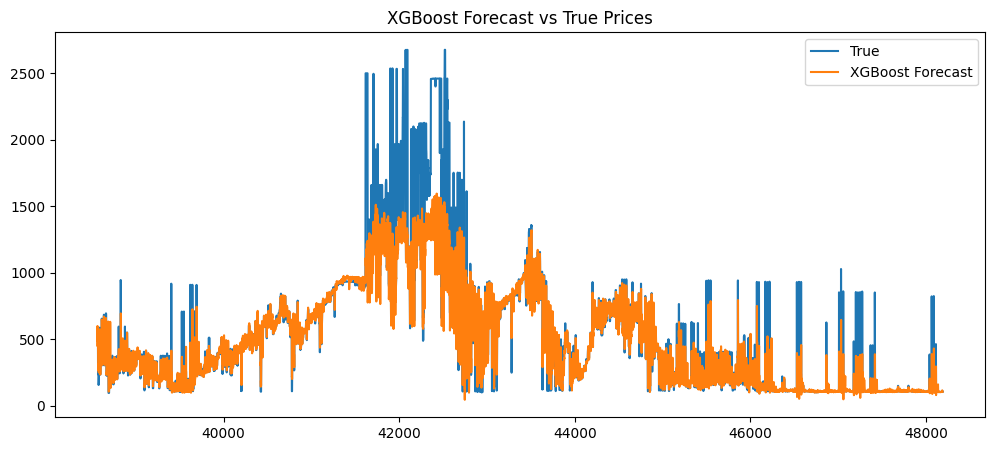

In [39]:
# ===========================================
# XGBoost Forecasting with Lags
# ===========================================

# Train XGBoost
model_xgb = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.1, max_depth=6)
model_xgb.fit(X_train, y_train)

# Predictions
pred_xgb = model_xgb.predict(X_test)

# Metrics
mae_x = mean_absolute_error(y_test, pred_xgb)
rmse_x = root_mean_squared_error(y_test, pred_xgb)
r2_x = r2_score(y_test, pred_xgb)

print("XGBoost Forecasting Results:")
print(f"MAE: {mae_x:.2f}, RMSE: {rmse_x:.2f}, R2: {r2_x:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="True")
plt.plot(y_test.index, pred_xgb, label="XGBoost Forecast")
plt.legend()
plt.title("XGBoost Forecast vs True Prices")
plt.show()

### Boosting with lags

In [40]:
models = {
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=-1, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_state=42, verbose=0)
}

In [41]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

df_results = pd.DataFrame(results).T
print(df_results)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001868 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7402
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 30
[LightGBM] [Info] Start training from score 318.370624
                MAE        RMSE        R2
XGBoost   81.771927  223.143313  0.801951
LightGBM  80.447331  220.762481  0.806155
CatBoost  80.638859  219.772945  0.807889


### Boosting with lags (tunning)

In [42]:
# ===================== OBJECTIVES =====================

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5)
    }

    model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = LGBMRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 12),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1)
    }

    model = CatBoostRegressor(**params, random_state=42, verbose=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE

In [43]:
# ===================== RUN STUDIES =====================

studies = {}
for name, objective in [("XGBoost", objective_xgb), 
                        ("LightGBM", objective_lgbm), 
                        ("CatBoost", objective_cat)]:
    print(f"Running Optuna for {name}...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100)  # puedes subir n_trials si quieres
    studies[name] = study
    print(f"Best params for {name}: {study.best_trial.params}")
    print(f"Best RMSE: {study.best_value:.4f}\n")


# ===================== FINAL EVALUATION =====================

results = {}
best_params = {}
best_scores = {}

for name, study in studies.items():
    if name == "XGBoost":
        model = XGBRegressor(**study.best_trial.params, random_state=42, n_jobs=-1)
    elif name == "LightGBM":
        model = LGBMRegressor(**study.best_trial.params, random_state=42)
    else:
        model = CatBoostRegressor(**study.best_trial.params, random_state=42, verbose=0)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    best_params[name] = study.best_trial.params
    best_scores[name] = study.best_value
    
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": root_mean_squared_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }


[I 2025-08-31 23:43:50,645] A new study created in memory with name: no-name-fd1b6e9d-067f-45d8-925d-8846f98ee4ec


Running Optuna for XGBoost...


[I 2025-08-31 23:43:53,281] Trial 0 finished with value: 233.29093410328815 and parameters: {'n_estimators': 339, 'learning_rate': 0.013171211258982277, 'max_depth': 9, 'subsample': 0.8639019906437573, 'colsample_bytree': 0.6812705878660309, 'gamma': 3.4988888026596814, 'reg_alpha': 4.022152360609639, 'reg_lambda': 2.782250656840435}. Best is trial 0 with value: 233.29093410328815.
[I 2025-08-31 23:43:57,748] Trial 1 finished with value: 230.72057521117947 and parameters: {'n_estimators': 447, 'learning_rate': 0.027949919855384534, 'max_depth': 10, 'subsample': 0.8321152298542802, 'colsample_bytree': 0.600118690541057, 'gamma': 2.984609685410434, 'reg_alpha': 0.4558364457528058, 'reg_lambda': 4.4321056940662835}. Best is trial 1 with value: 230.72057521117947.
[I 2025-08-31 23:43:58,194] Trial 2 finished with value: 218.64474771491277 and parameters: {'n_estimators': 351, 'learning_rate': 0.16110308527407408, 'max_depth': 4, 'subsample': 0.8306665191490017, 'colsample_bytree': 0.724147

Best params for XGBoost: {'n_estimators': 1064, 'learning_rate': 0.013695566185561375, 'max_depth': 3, 'subsample': 0.7964262237456903, 'colsample_bytree': 0.7587609617116091, 'gamma': 1.6523250807703154, 'reg_alpha': 1.8285016077979077, 'reg_lambda': 0.09760507573004008}
Best RMSE: 211.1863

Running Optuna for LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001918 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7402
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 30
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

[I 2025-08-31 23:47:18,340] Trial 0 finished with value: 214.9427516434403 and parameters: {'n_estimators': 396, 'learning_rate': 0.09477381457697148, 'num_leaves': 42, 'max_depth': 14, 'min_child_samples': 94, 'subsample': 0.8319694063488067, 'colsample_bytree': 0.6778220771353842}. Best is trial 0 with value: 214.9427516434403.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-08-31 23:48:52,005] Trial 99 finished with value: 213.68062150445704 and parameters: {'n_estimators': 1032, 'learning_rate': 0.014564343505201926, 'num_leaves': 38, 'max_depth': 4, 'min_child_samples': 47, 'subsample': 0.6642849335411465, 'colsample_bytree': 0.9252627335737489}. Best is trial 97 with value: 209.8981184957466.
[I 2025-08-31 23:48:52,005] A new study created in memory with name: no-name-5bb3f71b-5dff-4d37-a2c7-505c1f71d214


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-08-31 23:48:55,021] Trial 0 finished with value: 217.07489301238337 and parameters: {'iterations': 859, 'learning_rate': 0.07779664734146133, 'depth': 4, 'l2_leaf_reg': 6.193065553126646, 'bagging_temperature': 0.26628679698413804}. Best is trial 0 with value: 217.07489301238337.
[I 2025-08-31 23:49:58,366] Trial 1 finished with value: 238.13927388326204 and parameters: {'iterations': 1397, 'learning_rate': 0.05986205045920015, 'depth': 10, 'l2_leaf_reg': 7.806946478008601, 'bagging_temperature': 0.8141470903670451}. Best is trial 0 with value: 217.07489301238337.
[I 2025-08-31 23:50:05,568] Trial 2 finished with value: 217.67262644345573 and parameters: {'iterations': 1442, 'learning_rate': 0.08219814246993128, 'depth': 6, 'l2_leaf_reg': 7.414298343598654, 'bagging_temperature': 0.45273013824076913}. Best is trial 0 with value: 217.07489301238337.
[I 2025-08-31 23:50:19,336] Trial 3 finished with value: 219.4459727066873 and parameters: {'iterations': 1314, 'learning_rate': 0.

Best params for CatBoost: {'iterations': 1031, 'learning_rate': 0.10583474549843606, 'depth': 3, 'l2_leaf_reg': 6.5761764057624505, 'bagging_temperature': 0.020296477693926618}
Best RMSE: 211.2542

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002145 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7402
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 30
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

In [44]:
params_df = pd.DataFrame(best_params).T
params_df["Best_RMSE"] = pd.Series(best_scores)
results_df = pd.DataFrame(results).T

print("\n===== Best Hyperparameters per Model =====")
print(params_df)
print(results_df)


===== Best Hyperparameters per Model =====
          n_estimators  learning_rate  max_depth  subsample  colsample_bytree  \
XGBoost         1064.0       0.013696        3.0   0.796426          0.758761   
LightGBM        1131.0       0.014252        3.0   0.655526          0.926882   
CatBoost           NaN       0.105835        NaN        NaN               NaN   

             gamma  reg_alpha  reg_lambda  num_leaves  min_child_samples  \
XGBoost   1.652325   1.828502    0.097605         NaN                NaN   
LightGBM       NaN        NaN         NaN        39.0               98.0   
CatBoost       NaN        NaN         NaN         NaN                NaN   

          iterations  depth  l2_leaf_reg  bagging_temperature   Best_RMSE  
XGBoost          NaN    NaN          NaN                  NaN  211.186276  
LightGBM         NaN    NaN          NaN                  NaN  209.898118  
CatBoost      1031.0    3.0     6.576176             0.020296  211.254241  
                MAE   

### Baseline models with lag

In [45]:
# Entrenar cada modelo base con cross-validation
results_base = {}

# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

for name, model in baseline_models.items():
    scores = cross_validate(model, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results_base[name] = {
        metric: np.mean(scores[f"test_{metric}"]) for metric in scoring.keys()
    }

# Mostrar resultados
results_base_df = pd.DataFrame(results_base).T
print(results_base_df)

                         r2         mae           mse        rmse
Linear Regression  0.949638   26.153472   4529.216683   55.389212
Ridge              0.949638   26.153399   4529.215054   55.389151
Lasso              0.950685   25.981169   4523.908786   55.242267
ElasticNet         0.950564   26.012856   4525.560089   55.265028
Decision Tree      0.635228   79.362587  47632.995103  166.890531
Random Forest      0.805780   57.658166  27213.762880  122.611395
Gradient Boosting  0.833552   53.032480  25687.229882  116.645377
SVR               -0.075163  181.003210  88033.351862  253.531587
KNN                0.078872  154.195359  68628.215075  226.644890


### Baseline models (linear) with lag (tunning)

In [46]:
# ========================
# Setting
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

# Scorers
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "rmse": make_scorer(lambda y, y_pred: root_mean_squared_error(y, y_pred))
}

# ========================
# Linear models → GridSearchCV
# ========================

linear_grids = {
    "Linear Regression": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}),
    "Lasso": (Lasso(max_iter=5000), {"alpha": [0.001, 0.01, 0.1, 1, 10]}),
    "ElasticNet": (ElasticNet(max_iter=5000), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
}

In [47]:
results = {}

for name, (model, grid) in linear_grids.items():
    search = GridSearchCV(
        model,
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1
    )
    search.fit(X, y)
    best_model = search.best_estimator_

    # Cross-validate with multiple metrics
    scores = cross_val_score(best_model, X, y, cv=tscv, scoring="r2")
    r2 = scores.mean()
    scores_mae = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error")
    mae = -scores_mae.mean()
    scores_rmse = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    rmse = -scores_rmse.mean()

    results[name] = {
        "Best Params": search.best_params_,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_results = pd.DataFrame(results).T
df_results

,Best Params,R2,MAE,RMSE
Linear Regression,{},0.949638,26.153472,55.389212
Ridge,{'alpha': 100},0.949683,26.146429,55.383384
Lasso,{'alpha': 10},0.950721,25.952049,55.205788
ElasticNet,"{'alpha': 10, 'l1_ratio': 0.9}",0.95073,25.955003,55.205971


In [48]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959

### Baseline models (non-linear) with lag (tunning)

In [49]:
# ========================
# Non-linear models → Optuna
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

def optuna_objective(trial, model_name):
    
    if model_name == "Decision Tree":
        model = DecisionTreeRegressor(
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            random_state=42
        )

    elif model_name == "Random Forest":
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            n_jobs=-1, random_state=42
        )

    elif model_name == "Gradient Boosting":
        model = GradientBoostingRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            learning_rate=trial.suggest_float("learning_rate", 0.001, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 10),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            random_state=42
        )

    # CV RMSE
    scores = cross_val_score(model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    return -scores.mean()

In [50]:
nonlinear_models = ["Decision Tree", "Random Forest", "Gradient Boosting"]

In [51]:
nonlinear_results = {}

for name in nonlinear_models:
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: optuna_objective(trial, name), n_trials=30, n_jobs=-1)

    best_params = study.best_params

    # Entrenar con los mejores parámetros
    if name == "Decision Tree":
        best_model = DecisionTreeRegressor(**best_params, random_state=42)
    elif name == "Random Forest":
        best_model = RandomForestRegressor(**best_params, n_jobs=-1, random_state=42)
    elif name == "Gradient Boosting":
        best_model = GradientBoostingRegressor(**best_params, random_state=42)

    # Cross-validate with metrics
    r2 = cross_val_score(best_model, X, y, cv=tscv, scoring="r2").mean()
    mae = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error").mean()
    rmse = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error").mean()

    nonlinear_results[name] = {
        "Best Params": best_params,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_nonlinear_results = pd.DataFrame(nonlinear_results).T
df_nonlinear_results

[I 2025-09-01 00:08:51,460] A new study created in memory with name: no-name-249cd2b0-0c10-47c2-88ee-ada4042d30db
[I 2025-09-01 00:08:58,450] Trial 5 finished with value: 123.62691204575492 and parameters: {'max_depth': 3, 'min_samples_split': 3}. Best is trial 5 with value: 123.62691204575492.
[I 2025-09-01 00:08:59,864] Trial 7 finished with value: 159.48454725699253 and parameters: {'max_depth': 8, 'min_samples_split': 7}. Best is trial 5 with value: 123.62691204575492.
[I 2025-09-01 00:09:05,184] Trial 6 finished with value: 132.84093044244244 and parameters: {'max_depth': 6, 'min_samples_split': 4}. Best is trial 5 with value: 123.62691204575492.
[I 2025-09-01 00:09:06,886] Trial 14 finished with value: 164.19010699286838 and parameters: {'max_depth': 13, 'min_samples_split': 8}. Best is trial 5 with value: 123.62691204575492.
[I 2025-09-01 00:09:06,948] Trial 9 finished with value: 158.02536087074782 and parameters: {'max_depth': 13, 'min_samples_split': 9}. Best is trial 5 with 

,Best Params,R2,MAE,RMSE
Decision Tree,"{'max_depth': 4, 'min_samples_split': 14}",0.861512,49.32538,101.282835
Random Forest,"{'n_estimators': 490, 'max_depth': 5, 'min_sam...",0.87902,43.988748,96.409808
Gradient Boosting,"{'n_estimators': 835, 'learning_rate': 0.00319...",0.838067,54.774369,109.574824


In [52]:
nonlinear_results

{'Decision Tree': {'Best Params': {'max_depth': 4, 'min_samples_split': 14},
  'R2': 0.8615116142584689,
  'MAE': 49.32537968897613,
  'RMSE': 101.28283532873779},
 'Random Forest': {'Best Params': {'n_estimators': 490,
   'max_depth': 5,
   'min_samples_split': 11,
   'max_features': None},
  'R2': 0.8790204132196623,
  'MAE': 43.98874813643784,
  'RMSE': 96.409807968242},
 'Gradient Boosting': {'Best Params': {'n_estimators': 835,
   'learning_rate': 0.003198095336638223,
   'max_depth': 3,
   'subsample': 0.6246404680414033},
  'R2': 0.838067430268959,
  'MAE': 54.77436899728652,
  'RMSE': 109.57482377544575}}

In [53]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959
#Decision Tree	{'max_depth': 5, 'min_samples_split': 8}	0.852894	47.07064	98.828144
#Random Forest	{'n_estimators': 380, 'max_depth': 5, 'min_samples_split': 7,'max_features': None}	0.875931	44.651063	97.202218

In [54]:
# Random forest
#{'Best Params': {'n_estimators': 380,
#  'max_depth': 5,
#  'min_samples_split': 7,
#  'max_features': None},
# 'R2': 0.8759310854350622,
# 'MAE': 44.6510629713005,
# 'RMSE': 97.20221800266624}

In [55]:
#{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 17},
#  'R2': 0.8528940981487452,
#  'MAE': 47.07063996534437,
#  'RMSE': 98.82814400209875},
# 'Random Forest': {'Best Params': {'n_estimators': 407,
#   'max_depth': 4,
#   'min_samples_split': 16,
#   'max_features': None},
#  'R2': 0.8626976844486611,
#  'MAE': 47.776218604543374,
#  'RMSE': 101.92848807043003},
# 'Gradient Boosting': {'Best Params': {'n_estimators': 710,
#   'learning_rate': 0.004824184299163144,
#   'max_depth': 2,
#   'subsample': 0.54752888994856},
#  'R2': 0.8518062305030419,
#  'MAE': 50.53916588389959,
#  'RMSE': 103.0669818471433}}

results 0 with value: 98.0681054649906.

### Other robust models

In [56]:
# Nuevos modelos robustos
new_models = {
    "Extra Trees": ExtraTreesRegressor(n_jobs=-1, random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
    "MLP Regressor": MLPRegressor(random_state=42, max_iter=500)
}

In [57]:
# Evaluación
results_new = {}

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error"
}

for name, model in new_models.items():
    pipe = Pipeline(steps=[("model", model)])
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results_new[name] = {metric: abs(scores[f"test_{metric}"].mean()) if metric != "r2"
                         else scores[f"test_{metric}"].mean()
                         for metric in scoring.keys()}

df_results_new = pd.DataFrame(results_new).T
print(df_results_new)

                               r2          mae           mse         rmse
Extra Trees              0.919896    32.592570  1.226873e+04    75.812607
Hist Gradient Boosting   0.925199    31.232898  1.092229e+04    72.937349
MLP Regressor          -51.914447  1256.000977  6.182414e+06  1860.429733


<hr>

## Long short-term memory (LSTM)

In [58]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [59]:
# Numerical variables
print(numeric_features)

['TERMICA', 'HIDRAULICA', 'SOLAR', 'COGENERADOR', 'EOLICA']


In [60]:
# Scale numerical variables

# ============================
# 1. Prepare data
# ============================

scaler = MinMaxScaler()
df_scaled = df.copy().drop(columns=["FECHA_HORA"])
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])
df_scaled

,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,EOLICA,NIVEL_ENSO
0,72.02,0.363247,0.269862,0.000000,0.189648,0.100633,1.0
1,136.71,0.310187,0.286300,0.000000,0.191136,0.082356,1.0
2,127.71,0.278933,0.283414,0.000000,0.170337,0.061953,1.0
3,127.71,0.263346,0.274959,0.000000,0.168444,0.071108,1.0
4,127.71,0.276951,0.252457,0.000000,0.165776,0.058972,1.0
...,...,...,...,...,...,...,...
48187,112.55,0.190143,0.849097,0.001340,0.578630,0.547735,0.0
48188,112.55,0.191153,0.826843,0.000839,0.613528,0.549004,0.0
48189,106.25,0.204237,0.784387,0.000000,0.624925,0.546028,0.0
48190,105.55,0.209577,0.727481,0.000000,0.651119,0.546691,0.0


In [61]:
# ============================
# 2. Create sequences for LSTM
# ============================

def create_sequences(data, target_col="PRECIO", window_size=24):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:(i + window_size)].values)
        y.append(data.iloc[i + window_size, target_idx])
    
    return np.array(X), np.array(y)

look_back = 48
X, y = create_sequences(df_scaled, target_col="PRECIO", window_size=look_back)

print("X shape:", X.shape)  # (samples, timesteps, features)
print("y shape:", y.shape)

X shape: (48144, 48, 7)
y shape: (48144,)


In [62]:
# ============================
# 3. Train-Test split (time series, not random)
# ============================
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [63]:
# ============================
# 4. Model construction (Multivariate - Single step)
# ============================

n_features = X_train.shape[2]  # Número total de variables predictoras

model = Sequential()
model.add(LSTM(128, activation='tanh', return_sequences=True, input_shape=(look_back, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # salida para regresión

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping (para evitar sobreentrenamiento)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 48, 128)           69632     
                                                                 
 dropout (Dropout)           (None, 48, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 121153 (473.25 KB)
Trainable params: 121

In [64]:
# ============================
# 5. Train model

# ============================

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


482/482 [==============================] - 46s 89ms/step - loss: 36138.3828 - mae: 128.8584 - val_loss: 176202.7812 - val_mae: 334.2523
Epoch 2/50
482/482 [==============================] - 41s 86ms/step - loss: 4625.2500 - mae: 36.5105 - val_loss: 68249.0938 - val_mae: 173.1908
Epoch 3/50
482/482 [==============================] - 42s 87ms/step - loss: 2208.7090 - mae: 27.5826 - val_loss: 40532.2305 - val_mae: 125.4188
Epoch 4/50
482/482 [==============================] - 43s 88ms/step - loss: 1787.6830 - mae: 25.3435 - val_loss: 30093.3457 - val_mae: 106.2453
Epoch 5/50
482/482 [==============================] - 42s 87ms/step - loss: 1659.3905 - mae: 24.2435 - val_loss: 23263.8887 - val_mae: 90.5218
Epoch 6/50
482/482 [==============================] - 42s 87ms/step - loss: 1573.9496 - mae: 23.5752 - val_loss: 22218.7988 - val_mae: 92.5738
Epoch 7/50
482/482 [==============================] - 43s 89ms/step - loss: 1532.9619 - mae: 23.0586 - val_loss: 21277.2012 - val_mae

In [65]:

# ============================
# 6. Evaluation
# ============================

y_pred = model.predict(X_test)

y_test_inv = y_test
y_pred_inv = y_pred.flatten()

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"R2: {r2}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

301/301 [==============================] - 6s 16ms/step
R2: 0.582798348117735, RMSE: 323.9536, MAE: 121.4896


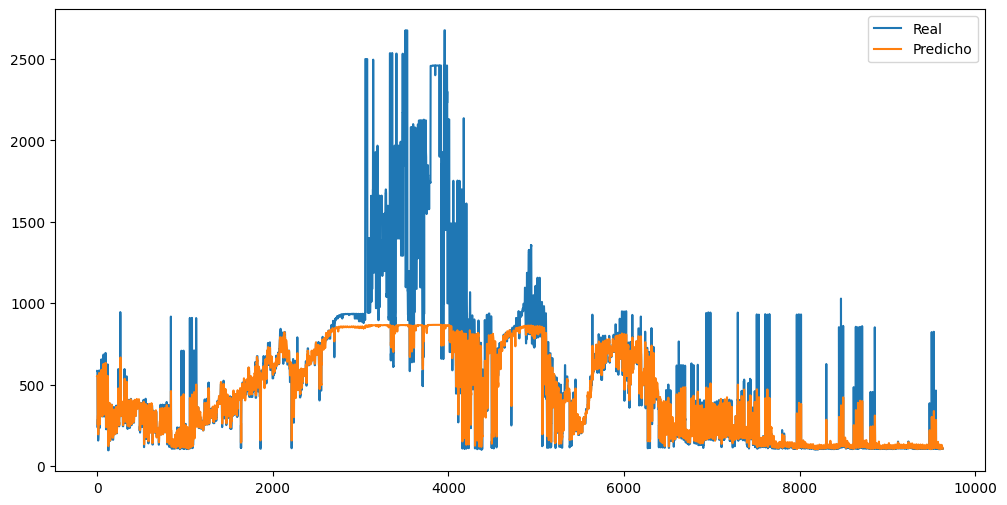

In [66]:
# ============================
# 7. Graphic
# ============================

plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Real")
plt.plot(y_pred_inv, label="Predicho")
plt.legend()
plt.show()